# Results Comparison and Analysis

**Model:** Comparison of all four coupling architectures (PA, PD, TA, TD)

## Overview

This notebook loads pre-computed results from saved .npz files and generates comprehensive comparison figures across all four Wilson-Cowan coupling architectures (Second-order Additive, Second-order Diffusive, Third-Order Additive, and Third-Order Diffusive). It visualizes how different coupling mechanisms lead to the emergence of higher-order statistical structure and evaluates the main findings of the paper 'Higher-order statistical structure emerges from nonlinear dynamics without explicit third-order coupling'.

## Key Sections

- **Load saved results:** Import parameter sweep data from results/ directory
- **Generate comparison figures:** Create visualizations comparing metrics across all four coupling architectures

---

In [1]:
import sys
import os
sys.path.append('../')  # Ensure Python can find the 'Scripts' folder
import numpy as np
from Scripts.visualization import *

pairwise = np.load("../results/metrics_Pairwise_noise.npz")
pairwise_diffusive = np.load("../results/metrics_Pairwise_diffusive_noise.npz")

couplin = np.load("../results/metrics_Coupling_noise.npz")
couplin_diffusive = np.load("../results/metrics_Coupling_diffusive_noise.npz")

pairwise_a = np.load("../results/metrics_Pairwise_noise_a.npz")
couplin_a = np.load("../results/metrics_Coupling_noise_a.npz")

metrics = ["oscillation_map","TC","DTC","cumulant","powercorr","skew","kurt"]

### Load Saved Results

Import parameter sweep results from saved .npz files in the results/ directory for all four coupling architectures.


In [2]:
import plotly.graph_objects as go
import numpy as np

def plot_metrics_contour(matrix, P_values, K_values, title="Metric Map",
                         colorscale="Inferno", n_contours=15, horizontal_lines=False,P1=0,P2=0, y_label=''):

    z_min = np.nanmin(matrix)
    z_max = np.nanmax(matrix)

    fig = go.Figure(data=go.Contour(
        z=matrix,
        x=K_values,
        y=P_values,
        colorscale=colorscale,
        contours=dict(
            start=z_min,
            end=z_max,
            size=(z_max - z_min) / n_contours,
            coloring='heatmap',
            showlines=True
        ),
        colorbar=dict(
            thickness=12,
            len=0.8
        )
    ))

    if horizontal_lines:
        # líneas horizontales
        fig.add_hline(y=P1, line=dict(color="lightblue", width=3), line_dash="dash")
        fig.add_hline(y=P2, line=dict(color="lightblue", width=3), line_dash="dash")
    
    fig.update_layout(
        title=title,
        xaxis_title='K',
        yaxis_title='P',
        width=500,
        height=400,
        margin=dict(l=60, r=40, t=50, b=50)
    )

    fig.show()
    fig.write_image(f"imgs/{title}.png")

### Generate Comparison Figures

Create comprehensive comparison visualizations showing how different coupling architectures lead to higher-order statistical structure emergence.


In [14]:
for m in metrics:
    plot_metrics_contour(pairwise[m] , pairwise["P"], pairwise["K3"], title=f"{m} Pairwise",y_label="P")
    plot_metrics_contour(couplin[m] , pairwise["P"], pairwise["K3"], title=f"{m} coupling",y_label="P")
    plot_metrics_contour(pairwise_diffusive[m] , pairwise["P"], pairwise["K3"], title=f"{m} Pairwise Diffusive",y_label="P")
    plot_metrics_contour(couplin_diffusive[m] , pairwise["P"], pairwise["K3"], title=f"{m} coupling Diffusive",y_label="P")

KeyboardInterrupt: 

### Generate Comparison Figures

Create comprehensive comparison visualizations showing how different coupling architectures lead to higher-order statistical structure emergence.


In [22]:
metrics = ["TC","DTC","cumulant","powercorr","skew","kurt"]
rms_values = {}

# calcular RMS de cada métrica
for m in metrics:
    rms_values[m] = np.sqrt(np.mean(diff[m]**2))

# ordenar de mayor a menor
rms_sorted = sorted(rms_values.items(), key=lambda x: x[1], reverse=True)

# imprimir ordenado
for m, v in rms_sorted:
    print(f"{m}: {v:.4f}")

powercorr: 0.8849
TC: 0.6237
cumulant: 0.5672
DTC: 0.5380
kurt: 0.4667
skew: 0.4042


In [23]:
metrics = ["TC","DTC","cumulant","powercorr","skew","kurt"]
rms_values = {}

# calcular RMS de cada métrica
for m in metrics:
    rms_values[m] = np.sqrt(np.mean(diff_diffusive[m]**2))

# ordenar de mayor a menor
rms_sorted = sorted(rms_values.items(), key=lambda x: x[1], reverse=True)

# imprimir ordenado
for m, v in rms_sorted:
    print(f"{m}: {v:.4f}")

cumulant: 1.8428
DTC: 0.8096
powercorr: 0.7770
TC: 0.7769
kurt: 0.4673
skew: 0.3080


In [ ]:
import plotly.graph_objects as go
import numpy as np

def plot_metrics_contour(matrix, oscillation_map, P_values, K_values,
                         title="Metric Map",
                         colorscale="Inferno",
                         n_contours=15,
                         horizontal_lines=False,
                         P1=0, P2=0,
                         y_label='P'):

    z_min = np.nanmin(matrix)
    z_max = np.nanmax(matrix)

    fig = go.Figure()

    # --- Heatmap principal ---
    fig.add_trace(go.Contour(
        z=matrix,
        x=K_values,
        y=P_values,
        colorscale=colorscale,
        contours=dict(
            start=z_min,
            end=z_max,
            size=(z_max - z_min) / n_contours,
            coloring='heatmap',
            showlines=True
        ),
        colorbar=dict(
            thickness=12,
            len=0.8
        )
    ))

    # --- Contorno de oscilaciones (forzado a cyan) ---
    fig.add_trace(go.Contour(
        z=oscillation_map,
        x=K_values,
        y=P_values,
        contours=dict(
            start=0.5,
            end=0.5,
            coloring="lines"
        ),
        line=dict(color="cyan", width=1, dash="dash"),
        colorscale=[[0, "cyan"], [1, "cyan"]],  # fuerza el color
        showscale=False
    ))

    if horizontal_lines:
        fig.add_hline(y=P1, line=dict(color="cyan", width=3, dash="dash"))
        fig.add_hline(y=P2, line=dict(color="cyan", width=3, dash="dash"))

    fig.update_layout(
        title=title,
        xaxis_title='K',
        yaxis_title=y_label,
        width=500,
        height=400,
        margin=dict(l=120, r=40, t=50, b=50)
    )

    fig.show()
    fig.write_image(f"imgs/{title}.png")

### Generate Comparison Figures

Create comprehensive comparison visualizations showing how different coupling architectures lead to higher-order statistical structure emergence.


In [4]:
datasets = {
    "pairwise": pairwise,
    "pairwise_diffusive": pairwise_diffusive,
    "coupling": couplin,
    "coupling_diffusive": couplin_diffusive,
    "pairwise_a": pairwise_a,
    "coupling_a": couplin_a
}

for name, data in datasets.items():

    oscillation = data["oscillation_map"]
    TC = data["TC"]
    DTC = data["DTC"]
    cumulant = data["cumulant"]

    tc_dtc = TC - DTC

    if name=='pairwise_a' or name=='coupling_a':
        P_values = np.linspace(0.5, 3, 20)
        K_values = np.linspace(0.0, 1.0, 20)
    else:
        P_values = np.linspace(0.0, 10, 20)
        K_values = np.linspace(0.0, 1.0, 20)
    

    if name=='pairwise_a' or name=='coupling_a':
        y_label = "slope a_e"
    else:
        y_label = "P"

    # --- TC - DTC ---
    plot_metrics_contour(
        tc_dtc,
        oscillation,
        P_values,
        K_values,
        title=f"{name}_TC_minus_DTC",
        y_label=y_label
    )

    # --- Cumulant ---
    plot_metrics_contour(
        cumulant,
        oscillation,
        P_values,
        K_values,
        title=f"{name}_cumulant",
        y_label=y_label
    )

### Generate Comparison Figures

Create comprehensive comparison visualizations showing how different coupling architectures lead to higher-order statistical structure emergence.


In [ ]:
import sys
import os
sys.path.append('../')  # Ensure Python can find the 'Scripts' folder
import numpy as np
from Scripts.visualization import *
import plotly.graph_objects as go

def plot_metrics_contour(matrix, oscillation_map, P_values, K_values,
                         title="Metric Map",
                         colorscale="Inferno",
                         n_contours=15,
                         horizontal_lines=False,
                         P1=0, P2=0,
                         y_label='P'):

    z_min = np.nanmin(matrix)
    z_max = np.nanmax(matrix)

    fig = go.Figure()

    # --- Heatmap principal ---
    fig.add_trace(go.Contour(
        z=matrix,
        x=K_values,
        y=P_values,
        colorscale=colorscale,
        contours=dict(
            start=z_min,
            end=z_max,
            size=(z_max - z_min) / n_contours,
            coloring='heatmap',
            showlines=True
        ),
        colorbar=dict(
            thickness=12,
            len=0.8
        )
    ))

    # --- Contorno de oscilaciones (forzado a cyan) ---
    fig.add_trace(go.Contour(
        z=oscillation_map,
        x=K_values,
        y=P_values,
        contours=dict(
            start=0.5,
            end=0.5,
            coloring="lines"
        ),
        line=dict(color="cyan", width=1, dash="dash"),
        colorscale=[[0, "cyan"], [1, "cyan"]],  # fuerza el color
        showscale=False
    ))

    if horizontal_lines:
        fig.add_hline(y=P1, line=dict(color="cyan", width=3, dash="dash"))
        fig.add_hline(y=P2, line=dict(color="cyan", width=3, dash="dash"))

    fig.update_layout(
        title=title,
        xaxis_title='K',
        yaxis_title=y_label,
        width=500,
        height=400,
        margin=dict(l=60, r=40, t=50, b=50)
    )

    fig.show()
    fig.write_image(f"imgs/{title}.png")




pairwise = np.load("../results/raw_metrics_Pairwise_noise.npz")
pairwise_diffusive = np.load("../results/raw_metrics_Pairwise_diffusive_noise.npz")

couplin = np.load("../results/raw_metrics_Coupling_noise.npz")
couplin_diffusive = np.load("../results/raw_metrics_Coupling_diffusive_noise.npz")

pairwise_a = np.load("../results/raw_metrics_Pairwise_noise_a.npz")
couplin_a = np.load("../results/raw_metrics_Coupling_noise_a.npz")



metrics = ["oscillation_map","TC","DTC","cumulant","powercorr","skew","kurt"]

### Load Saved Results

Import parameter sweep results from saved .npz files in the results/ directory for all four coupling architectures.


In [ ]:
pairwise = np.load("../results/raw_metrics_Pairwise_noise.npz")
pairwise_diffusive = np.load("../results/raw_metrics_Pairwise_diffusive_noise.npz")

couplin = np.load("../results/raw_metrics_Coupling_noise.npz")
couplin_diffusive = np.load("../results/raw_metrics_Coupling_diffusive_noise.npz")

pairwise_a = np.load("../results/raw_metrics_Pairwise_noise_a.npz")
couplin_a = np.load("../results/raw_metrics_Coupling_noise_a.npz")

metrics = ["oscillation_map","TC","DTC","cumulant","powercorr","skew","kurt"]


datasets = {
    "pairwise": pairwise,
    "pairwise_diffusive": pairwise_diffusive,
    "coupling": couplin,
    "coupling_diffusive": couplin_diffusive,
    "pairwise_a": pairwise_a,
    "coupling_a": couplin_a
}

for name, data in datasets.items():

    oscillation = data["oscillation_map"]
    TC = data["TC"]
    DTC = data["DTC"]
    cumulant = data["cumulant"]

    tc_dtc = TC - DTC

    if name=='pairwise_a' or name=='coupling_a':
        P_values = np.linspace(0.5, 3, 20)
        K_values = np.linspace(0.0, 1.0, 20)
    else:
        P_values = np.linspace(0.0, 10, 20)
        K_values = np.linspace(0.0, 1.0, 20)
    

    if name=='pairwise_a' or name=='coupling_a':
        y_label = "slope a_e"
    else:
        y_label = "P"

    # --- TC - DTC ---
    plot_metrics_contour(
        tc_dtc,
        oscillation,
        P_values,
        K_values,
        title=f"{name}_TC_minus_DTC",
        y_label=y_label
    )

    # --- Cumulant ---
    plot_metrics_contour(
        cumulant,
        oscillation,
        P_values,
        K_values,
        title=f"{name}_cumulant",
        y_label=y_label
    )

### Load Saved Results

Import parameter sweep results from saved .npz files in the results/ directory for all four coupling architectures.


Saved → ../results/fig1_PK_additive.pdf
Saved → ../results/fig2_PK_diffusive.pdf
Saved → ../results/fig3_aK_additive.pdf


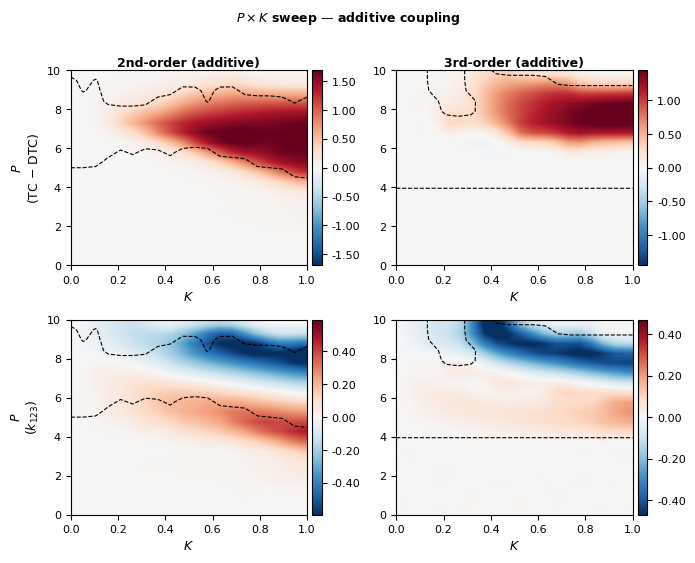

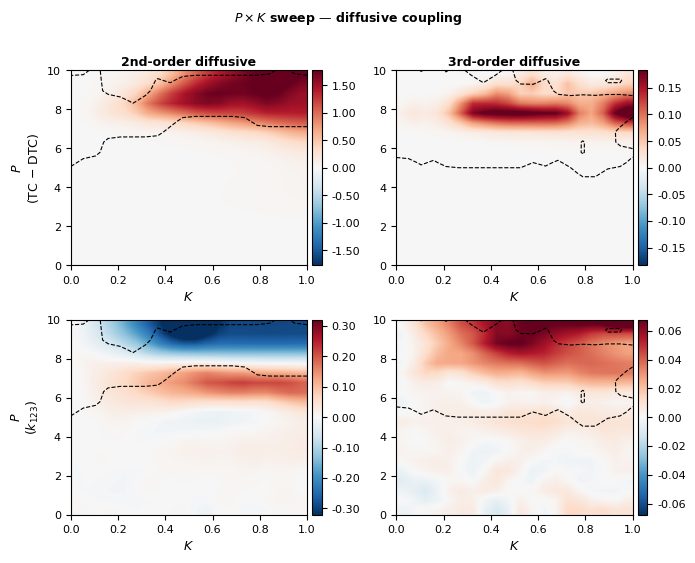

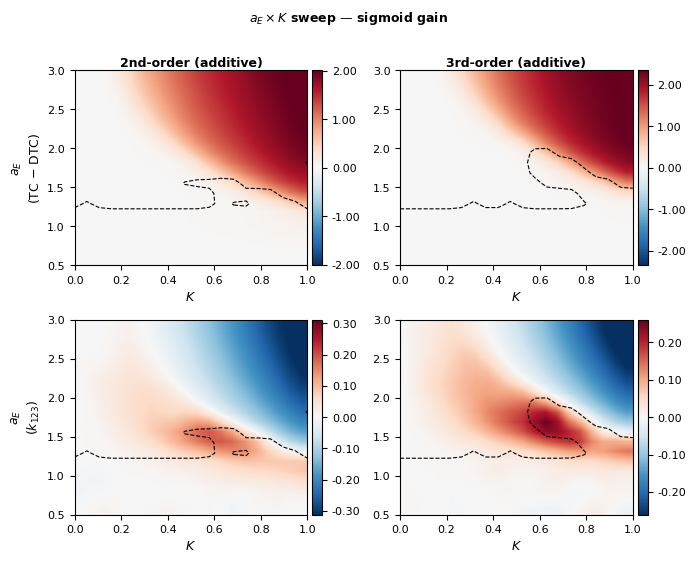

Done.


In [9]:
"""
plot_smooth_metrics.py
-----------------------
Smoothing + imputation of Wilson-Cowan metric matrices and
generation of 3 publication-quality figures for a 2-column RevTeX paper.

Smoothing pipeline per matrix:
  1. Outlier detection  – Z-score on the raw values; cells |z| > z_thresh
                          are flagged as outliers.
  2. Imputation         – flagged cells are replaced by the median of their
                          8 immediate neighbours (iterative, up to max_iter).
  3. Gaussian smoothing – light Gaussian blur (sigma tunable) to ensure
                          spatial continuity without over-smoothing structure.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter, generic_filter
from scipy.stats import zscore

import matplotlib as mpl
mpl.rcParams.update({
    'font.size':        8,
    'axes.titlesize':   8,
    'axes.labelsize':   8,
    'xtick.labelsize':  7,
    'ytick.labelsize':  7,
    'legend.fontsize':  7,
})


# ── 0.  Load data ────────────────────────────────────────────────────────────

pairwise           = np.load("../results/raw_metrics_Pairwise_noise.npz")
pairwise_diffusive = np.load("../results/raw_metrics_Pairwise_diffusive_noise.npz")
coupling           = np.load("../results/raw_metrics_Coupling_noise.npz")
coupling_diffusive = np.load("../results/raw_metrics_Coupling_diffusive_noise.npz")
pairwise_a         = np.load("../results/raw_metrics_Pairwise_noise_a.npz")
coupling_a         = np.load("../results/raw_metrics_Coupling_noise_a.npz")


# ── 1.  Smoothing / imputation helpers ───────────────────────────────────────

def detect_outliers(mat: np.ndarray, z_thresh: float = 2.5) -> np.ndarray:
    """Return boolean mask: True where value is an isolated outlier."""
    z = np.abs(zscore(mat.ravel()))
    mask = z.reshape(mat.shape) > z_thresh
    return mask


def neighbour_median(values: np.ndarray) -> float:
    """Footprint function: median of the 8-neighbourhood (centre excluded)."""
    centre_idx = len(values) // 2
    neighbours = np.concatenate([values[:centre_idx], values[centre_idx + 1:]])
    valid = neighbours[~np.isnan(neighbours)]
    return np.median(valid) if len(valid) > 0 else np.nan


def impute_outliers(mat: np.ndarray,
                    mask: np.ndarray,
                    max_iter: int = 10) -> np.ndarray:
    """
    Replace masked (outlier) cells iteratively with the median of their
    8 neighbours until no outlier remains or max_iter is reached.
    """
    work = mat.astype(float).copy()
    work[mask] = np.nan                          # flag outliers as NaN

    footprint = np.ones((3, 3), dtype=bool)      # 3×3 neighbourhood
    footprint[1, 1] = False                       # exclude centre

    for _ in range(max_iter):
        nan_mask = np.isnan(work)
        if not nan_mask.any():
            break
        # generic_filter treats NaN gracefully inside neighbour_median
        filled = generic_filter(work, neighbour_median,
                                footprint=footprint, mode='nearest')
        work[nan_mask] = filled[nan_mask]

    # If any NaN remains (isolated corner), fall back to global median
    if np.isnan(work).any():
        work[np.isnan(work)] = np.nanmedian(work)

    return work


def smooth_matrix(mat: np.ndarray,
                  z_thresh: float = 2.5,
                  sigma: float = 0.8,
                  max_iter: int = 10) -> np.ndarray:
    """Full pipeline: detect → impute → Gaussian blur."""
    mask      = detect_outliers(mat, z_thresh=z_thresh)
    imputed   = impute_outliers(mat, mask, max_iter=max_iter)
    smoothed  = gaussian_filter(imputed, sigma=sigma)
    return smoothed


# ── 2.  Metric extraction helper ─────────────────────────────────────────────

def get_metrics(data, a_sweep: bool = False):
    """Return (tc_dtc, cumulant, oscillation, P_vals, K_vals, y_label)."""
    TC        = data["TC"]
    DTC       = data["DTC"]
    cumulant  = data["cumulant"]
    oscillation = data["oscillation_map"]

    tc_dtc = TC - DTC

    K_values = np.linspace(0.0, 1.0, 20)
    if a_sweep:
        P_values = np.linspace(0.5, 3.0, 20)
        y_label  = r"$a_E$"
    else:
        P_values = np.linspace(0.0, 10.0, 20)
        y_label  = r"$P$"

    return tc_dtc, cumulant, oscillation, P_values, K_values, y_label


# ── 3.  Single-panel plot function ───────────────────────────────────────────

def plot_panel(ax, matrix, oscillation, x_vals, y_vals,
               title="", xlabel="K", ylabel="",
               cmap="RdBu_r", show_osc=True,
               z_thresh=2.5, sigma=0.8):
    """
    Draw one smoothed heatmap panel with optional oscillation contour overlay.
    """
    smoothed = smooth_matrix(matrix, z_thresh=z_thresh, sigma=sigma)

    # Symmetric colour scale centred on zero when data spans both signs
    vmax = np.nanpercentile(np.abs(smoothed), 98)
    vmin = -vmax if (smoothed.min() < 0 < smoothed.max()) else 0

    im = ax.imshow(
        smoothed,
        origin='lower',
        aspect='auto',
        extent=[x_vals[0], x_vals[-1], y_vals[0], y_vals[-1]],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation='bilinear',
    )

    # Oscillation contour (border between fixed-point and oscillatory regime)
    if show_osc and oscillation is not None:
        osc_smooth = gaussian_filter(oscillation.astype(float), sigma=0.6)
        ax.contour(
            np.linspace(x_vals[0], x_vals[-1], oscillation.shape[1]),
            np.linspace(y_vals[0], y_vals[-1], oscillation.shape[0]),
            osc_smooth,
            levels=[0.5],
            colors='k',
            linewidths=0.8,
            linestyles='--',
        )

    cb = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cb.ax.tick_params(labelsize=8)
    cb.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    ax.set_title(title, fontsize=9, fontweight='bold', pad=3)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=8)
    #axes[row, 0].set_ylabel(f"{ylL}\n({row_labels[row]})", fontsize=9)

    return im


# ── 4.  Figure factory ───────────────────────────────────────────────────────
# RevTeX 2-column: single column ≈ 3.4 in, full width ≈ 7.0 in.
# Each compound figure spans the full width with 2 columns of panels.

FIG_W  = 7.0    # inches – full two-column width
FIG_H  = 5.5    # inches – two metric rows look balanced at this height
FONTSIZE_SUPTITLE = 9


def make_figure(left_data, right_data,
                left_title, right_title,
                a_sweep_left=False, a_sweep_right=False,
                fig_title="", savepath=None,
                z_thresh=2.5, sigma=0.8):
    """
    Build a 2×2 figure:
        col 0 = left model  |  col 1 = right model
        row 0 = TC − DTC    |  row 1 = 3rd-order cumulant
    """
    tc_dtc_L, cum_L, osc_L, P_L, K_L, ylab_L = get_metrics(left_data,  a_sweep=a_sweep_left)
    tc_dtc_R, cum_R, osc_R, P_R, K_R, ylab_R = get_metrics(right_data, a_sweep=a_sweep_right)

    fig, axes = plt.subplots(2, 2, figsize=(FIG_W, FIG_H))
    fig.suptitle(fig_title, fontsize=FONTSIZE_SUPTITLE, fontweight='bold', y=1.01)

    row_labels = [r"TC $-$ DTC", r"$k_{123}$"]
    data_pairs = [
        (tc_dtc_L, osc_L, P_L, K_L, ylab_L,
         tc_dtc_R, osc_R, P_R, K_R, ylab_R),
        (cum_L,    osc_L, P_L, K_L, ylab_L,
         cum_R,    osc_R, P_R, K_R, ylab_R),
    ]

    for row, (dL, oL, PL, KL, ylL,
              dR, oR, PR, KR, ylR) in enumerate(data_pairs):

        col_title_L = left_title  if row == 0 else ""
        col_title_R = right_title if row == 0 else ""

        # ── left panel
        plot_panel(axes[row, 0], dL, oL,
                   x_vals=KL, y_vals=PL,
                   title=col_title_L,
                   xlabel=r"$K$", ylabel=ylL,
                   z_thresh=z_thresh, sigma=sigma)
        # row label on left y-axis (secondary)
        axes[row, 0].set_ylabel(f"{ylL}\n({row_labels[row]})", fontsize=9)

        # ── right panel
        plot_panel(axes[row, 1], dR, oR,
                   x_vals=KR, y_vals=PR,
                   title=col_title_R,
                   xlabel=r"$K$", ylabel=ylR,
                   z_thresh=z_thresh, sigma=sigma)
        axes[row, 1].set_ylabel("")   # avoid redundant y-label on right column

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f"Saved → {savepath}")
    return fig


# ── 5.  Generate the three figures ───────────────────────────────────────────

# ── Figure 1:  P vs K  |  2nd-order  vs  3rd-order  (additive) ──────────────
make_figure(
    left_data    = pairwise,
    right_data   = coupling,
    left_title   = "2nd-order (additive)",
    right_title  = "3rd-order (additive)",
    a_sweep_left = False, a_sweep_right = False,
    fig_title    = r"$P \times K$ sweep — additive coupling",
    savepath     = "../results/fig1_PK_additive.pdf",
)

# ── Figure 2:  P vs K  |  2nd-order diffusive  vs  3rd-order diffusive ───────
make_figure(
    left_data    = pairwise_diffusive,
    right_data   = coupling_diffusive,
    left_title   = "2nd-order diffusive",
    right_title  = "3rd-order diffusive",
    a_sweep_left = False, a_sweep_right = False,
    fig_title    = r"$P \times K$ sweep — diffusive coupling",
    savepath     = "../results/fig2_PK_diffusive.pdf",
)

# ── Figure 3:  a_E vs K  |  2nd-order  vs  3rd-order  (additive) ─────────────
make_figure(
    left_data    = pairwise_a,
    right_data   = coupling_a,
    left_title   = "2nd-order (additive)",
    right_title  = "3rd-order (additive)",
    a_sweep_left = True, a_sweep_right = True,
    fig_title    = r"$a_E \times K$ sweep — sigmoid gain",
    savepath     = "../results/fig3_aK_additive.pdf",
)

plt.show()
print("Done.")

### Load Saved Results

Import parameter sweep results from saved .npz files in the results/ directory for all four coupling architectures.


In [8]:
"""
extract_paper_stats.py
-----------------------
Extracts all numerical summaries needed to write §3 and §5 of the paper.
Run this once and share the printed output + saved JSON with Claude.

Output:
  - results/paper_stats.json   (machine-readable, share with Claude)
  - printed summary             (copy-paste friendly)
"""

import numpy as np
import json
from scipy.ndimage import gaussian_filter

# ── Load all datasets ────────────────────────────────────────────────────────
pairwise           = np.load("../results/raw_metrics_Pairwise_noise.npz")
pairwise_diffusive = np.load("../results/raw_metrics_Pairwise_diffusive_noise.npz")
coupling           = np.load("../results/raw_metrics_Coupling_noise.npz")
coupling_diffusive = np.load("../results/raw_metrics_Coupling_diffusive_noise.npz")
pairwise_a         = np.load("../results/raw_metrics_Pairwise_noise_a.npz")
coupling_a         = np.load("../results/raw_metrics_Coupling_noise_a.npz")

datasets_PK = {
    "pairwise":           pairwise,
    "pairwise_diffusive": pairwise_diffusive,
    "coupling":           coupling,
    "coupling_diffusive": coupling_diffusive,
}
datasets_AK = {
    "pairwise_a": pairwise_a,
    "coupling_a": coupling_a,
}

P_values = np.linspace(0.0, 10.0, 20)
K_values = np.linspace(0.0,  1.0, 20)
A_values = np.linspace(0.5,  3.0, 20)

stats = {}   # will be serialized to JSON

# ── Helper: basic stats of a 2D matrix ──────────────────────────────────────
def matrix_stats(mat, label=""):
    mat = np.array(mat, dtype=float)
    finite = mat[np.isfinite(mat)]
    s = {
        "min":    float(np.nanmin(finite)),
        "max":    float(np.nanmax(finite)),
        "mean":   float(np.nanmean(finite)),
        "median": float(np.nanmedian(finite)),
        "std":    float(np.nanstd(finite)),
        "n_nan":  int(np.sum(~np.isfinite(mat))),
    }
    return s

# ── Helper: oscillation regime statistics ───────────────────────────────────
def oscillation_stats(osc_map, P_vals, K_vals):
    """
    osc_map: 2D bool/float array (rows=P, cols=K)
    Returns fraction oscillating, and approximate P/K boundary.
    """
    osc = np.array(osc_map, dtype=float)
    frac = float(np.nanmean(osc > 0.5))

    # find approximate P threshold for oscillation onset (per K column)
    P_thresh = []
    for ki in range(osc.shape[1]):
        col = osc[:, ki]
        osc_rows = np.where(col > 0.5)[0]
        if len(osc_rows) > 0:
            P_thresh.append(float(P_vals[osc_rows[0]]))
        else:
            P_thresh.append(None)

    # find approximate K threshold for oscillation onset (per P row)
    K_thresh = []
    for pi in range(osc.shape[0]):
        row = osc[pi, :]
        osc_cols = np.where(row > 0.5)[0]
        if len(osc_cols) > 0:
            K_thresh.append(float(K_vals[osc_cols[0]]))
        else:
            K_thresh.append(None)

    return {
        "fraction_oscillating": frac,
        "P_threshold_per_K":    P_thresh,
        "K_threshold_per_P":    K_thresh,
    }

# ── Helper: metric stats split by regime ────────────────────────────────────
def regime_split_stats(metric, osc_map, label=""):
    """Compare metric values inside vs outside oscillatory regime."""
    osc  = np.array(osc_map, dtype=float) > 0.5
    vals = np.array(metric, dtype=float)

    in_osc  = vals[osc  & np.isfinite(vals)]
    out_osc = vals[~osc & np.isfinite(vals)]

    s = {
        "oscillatory_mean":   float(np.mean(in_osc))  if len(in_osc)  > 0 else None,
        "oscillatory_max":    float(np.max(in_osc))   if len(in_osc)  > 0 else None,
        "oscillatory_median": float(np.median(in_osc))if len(in_osc)  > 0 else None,
        "fixed_point_mean":   float(np.mean(out_osc)) if len(out_osc) > 0 else None,
        "fixed_point_max":    float(np.max(out_osc))  if len(out_osc) > 0 else None,
        "fixed_point_median": float(np.median(out_osc))if len(out_osc)> 0 else None,
        "ratio_osc_to_fp":    (float(np.mean(in_osc)/np.mean(out_osc))
                               if len(in_osc)>0 and len(out_osc)>0
                                  and np.mean(out_osc)!=0 else None),
    }
    return s

# ── Helper: location of maximum ─────────────────────────────────────────────
def argmax_2d(mat, row_vals, col_vals):
    mat = np.array(mat, dtype=float)
    mat[~np.isfinite(mat)] = -np.inf
    idx = np.unravel_index(np.argmax(mat), mat.shape)
    return {
        "row_idx": int(idx[0]),
        "col_idx": int(idx[1]),
        "row_val": float(row_vals[idx[0]]),
        "col_val": float(col_vals[idx[1]]),
        "value":   float(mat[idx]),
    }

# ── Process PK datasets ──────────────────────────────────────────────────────
print("=" * 60)
print("P × K  DATASETS")
print("=" * 60)

for name, data in datasets_PK.items():
    print(f"\n── {name} ──")
    stats[name] = {}

    osc = data["oscillation_map"]
    TC  = data["TC"]
    DTC = data["DTC"]
    cum = data["cumulant"]
    tc_dtc = TC - DTC

    # oscillation map
    osc_s = oscillation_stats(osc, P_values, K_values)
    stats[name]["oscillation"] = osc_s
    print(f"  Oscillating fraction: {osc_s['fraction_oscillating']:.2%}")

    # per-metric global stats
    for metric_name, metric_mat in [("TC", TC), ("DTC", DTC),
                                     ("TC_minus_DTC", tc_dtc), ("cumulant", cum)]:
        ms = matrix_stats(metric_mat)
        rs = regime_split_stats(metric_mat, osc)
        am = argmax_2d(metric_mat, P_values, K_values)
        stats[name][metric_name] = {"global": ms, "by_regime": rs, "argmax": am}

        print(f"  {metric_name:15s}  min={ms['min']:+.4f}  max={ms['max']:+.4f}"
              f"  mean={ms['mean']:+.4f}  std={ms['std']:.4f}")
        print(f"    max at P={am['row_val']:.2f}, K={am['col_val']:.2f}"
              f"  | osc_mean={rs['oscillatory_mean']}  fp_mean={rs['fixed_point_mean']}")

# ── Process AK datasets ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("a_E × K  DATASETS")
print("=" * 60)

for name, data in datasets_AK.items():
    print(f"\n── {name} ──")
    stats[name] = {}

    osc = data["oscillation_map"]
    TC  = data["TC"]
    DTC = data["DTC"]
    cum = data["cumulant"]
    tc_dtc = TC - DTC

    osc_s = oscillation_stats(osc, A_values, K_values)
    stats[name]["oscillation"] = osc_s
    print(f"  Oscillating fraction: {osc_s['fraction_oscillating']:.2%}")

    for metric_name, metric_mat in [("TC", TC), ("DTC", DTC),
                                     ("TC_minus_DTC", tc_dtc), ("cumulant", cum)]:
        ms = matrix_stats(metric_mat)
        rs = regime_split_stats(metric_mat, osc)
        am = argmax_2d(metric_mat, A_values, K_values)
        stats[name][metric_name] = {"global": ms, "by_regime": rs, "argmax": am}

        print(f"  {metric_name:15s}  min={ms['min']:+.4f}  max={ms['max']:+.4f}"
              f"  mean={ms['mean']:+.4f}  std={ms['std']:.4f}")
        print(f"    max at a_E={am['row_val']:.2f}, K={am['col_val']:.2f}"
              f"  | osc_mean={rs['oscillatory_mean']}  fp_mean={rs['fixed_point_mean']}")

# ── Cross-model comparison ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CROSS-MODEL COMPARISON  (TC-DTC and cumulant maxima)")
print("=" * 60)

comparison = {}
for name in datasets_PK:
    d = stats[name]
    comparison[name] = {
        "TC_DTC_max":       d["TC_minus_DTC"]["global"]["max"],
        "TC_DTC_osc_mean":  d["TC_minus_DTC"]["by_regime"]["oscillatory_mean"],
        "TC_DTC_fp_mean":   d["TC_minus_DTC"]["by_regime"]["fixed_point_mean"],
        "cum_max":          d["cumulant"]["global"]["max"],
        "cum_osc_mean":     d["cumulant"]["by_regime"]["oscillatory_mean"],
        "cum_fp_mean":      d["cumulant"]["by_regime"]["fixed_point_mean"],
    }
    print(f"  {name:25s}  TC-DTC max={comparison[name]['TC_DTC_max']:+.4f}"
          f"  cum max={comparison[name]['cum_max']:+.4f}")

stats["cross_model_PK"] = comparison

# ── Save JSON ────────────────────────────────────────────────────────────────
out_path = "../results/paper_stats.json"
with open(out_path, "w") as f:
    json.dump(stats, f, indent=2, default=str)

print(f"\n✓  Stats saved to {out_path}")
print("   → Share paper_stats.json with Claude to write §3 and §5.")

P × K  DATASETS

── pairwise ──
  Oscillating fraction: 31.75%
  TC               min=+0.0001  max=+4.9426  mean=+1.1320  std=1.5442
    max at P=6.32, K=0.95  | osc_mean=2.6345912464486734  fp_mean=0.43306388887869773
  DTC              min=+0.0001  max=+2.8217  mean=+0.7874  std=0.9865
    max at P=7.89, K=1.00  | osc_mean=1.6755041527048962  fp_mean=0.3742020231383175
  TC_minus_DTC     min=-0.0115  max=+2.1968  mean=+0.3447  std=0.6136
    max at P=5.79, K=1.00  | osc_mean=0.9590870937437765  fp_mean=0.058861865740380284
  cumulant         min=-5.6596  max=+0.6151  mean=-0.0415  std=0.3784
    max at P=4.21, K=1.00  | osc_mean=-0.0677413116593592  fp_mean=-0.029354557352305036

── pairwise_diffusive ──
  Oscillating fraction: 25.00%
  TC               min=+0.0002  max=+5.4925  mean=+0.9692  std=1.5078
    max at P=9.47, K=1.00  | osc_mean=2.5062544951967025  fp_mean=0.45685849440743237
  DTC              min=+0.0002  max=+3.0049  mean=+0.6514  std=0.9008
    max at P=9.47, K=1.00  

### Load Saved Results

Import parameter sweep results from saved .npz files in the results/ directory for all four coupling architectures.


In [3]:
"""
generate_oscillation_gif.py
────────────────────────────
Genera un GIF animado de las oscilaciones Wilson-Cowan.
Layout: 3 filas x 2 columnas
  - Columna izquierda : E(t) vs tiempo  (se va dibujando en tiempo real)
  - Columna derecha   : diagrama de fase (E vs I)

Paleta tomada del index.html del artículo:
  navy   #003d5c  |  teal  #005f87  |  sky   #0088bb
  accent #e8a020  |  fondo #eef3f7

Uso:
    python generate_oscillation_gif.py
Salida:
    oscillation.gif   (~3-5 MB, listo para GitHub Pages)

Dependencias:
    pip install matplotlib numpy pillow
"""

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation, PillowWriter

# ── 1. Parámetros de la simulación ───────────────────────────────────────────
# Puedes reemplazar estas secciones con tu función real de simulación.
# Aquí generamos datos sintéticos para que el script sea autónomo.

def sigmoid(x, a=1.5):
    return 1.0 / (1.0 + np.exp(-a * x))

def wc_rhs_simple(state, P=4.5, K=0.8,
                  cEE=6.0, cEI=15.0, cIE=8.0, cII=0.4,
                  aE=1.5, aI=1.0, Q=-2.0, tauE=0.125, tauI=0.25):
    """Wilson-Cowan 3 nodos, acoplamiento pairwise additive simplificado."""
    N = 3
    M = np.array([[0,1,1],[1,0,1],[1,1,0]], dtype=float)
    E = state[:N]
    I = state[N:]
    coupling = K * (M @ E)
    dE = np.zeros(N)
    dI = np.zeros(N)
    for i in range(N):
        dE[i] = (-E[i] + sigmoid(cEE*E[i] - cEI*I[i] + P + coupling[i], aE)) / tauE
        dI[i] = (-I[i] + sigmoid(cIE*E[i] - cII*I[i] + Q, aI)) / tauI
    return np.concatenate([dE, dI])

def rk4(f, state, dt):
    k1 = f(state)
    k2 = f(state + 0.5*dt*k1)
    k3 = f(state + 0.5*dt*k2)
    k4 = f(state + dt*k3)
    return state + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

def simulate(T=20.0, dt=1e-3, sigma=0.03, seed=42):
    rng = np.random.default_rng(seed)
    n   = int(T / dt)
    N   = 3
    state = 0.1 * rng.standard_normal(2*N)
    states = np.zeros((n, 2*N))
    states[0] = state
    for i in range(1, n):
        states[i] = rk4(wc_rhs_simple, states[i-1], dt)
        states[i, :N] += sigma * np.sqrt(dt) * rng.standard_normal(N)
    return states

print("Simulando…")
states_full = simulate(T=25.0)
# Descartar transitorio (20 %)
cut = int(0.20 * len(states_full))
states = states_full[cut:]
N_nodes = 3
E_all = states[:, :N_nodes]
I_all = states[:, N_nodes:]
dt    = 1e-3
t_arr = np.arange(len(states)) * dt

# ── 2. Paleta ────────────────────────────────────────────────────────────────
BG      = "#eef3f7"       # fondo claro del sitio
NAVY    = "#003d5c"
TEAL    = "#005f87"
SKY     = "#0088bb"
ACCENT  = "#e8a020"

# Colores pastel para cada nodo (van bien sobre fondo claro)
NODE_COLORS = [
    "#6baed6",   # pastel blue  – Node 1
    "#74c476",   # pastel green – Node 2
    "#fd8d3c",   # pastel orange– Node 3
]
PHASE_ALPHA = 0.35   # rastro de la trayectoria completa en el diagrama de fase

# ── 3. Configuración de la figura ────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family":      "serif",
    "font.size":        9,
    "axes.titlesize":   9,
    "axes.labelsize":   9,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

FIG_W, FIG_H = 7.0, 6.2
fig = plt.figure(figsize=(FIG_W, FIG_H), facecolor=BG)

gs = gridspec.GridSpec(
    N_nodes, 2,
    figure=fig,
    left=0.09, right=0.97,
    top=0.90,  bottom=0.09,
    hspace=0.55, wspace=0.38,
)

ax_t = []   # columna izquierda: E(t)
ax_p = []   # columna derecha:   phase

for n in range(N_nodes):
    at = fig.add_subplot(gs[n, 0])
    ap = fig.add_subplot(gs[n, 1])
    ax_t.append(at)
    ax_p.append(ap)

# Títulos de columna
ax_t[0].set_title("Excitatory signal  $E(t)$",
                   fontsize=9, color=NAVY, pad=4)
ax_p[0].set_title("Phase portrait  $(E,\\ I)$",
                   fontsize=9, color=NAVY, pad=4)

# Etiquetas de fila
node_labels = ["Node 1", "Node 2", "Node 3"]

# Límites fijos
E_min, E_max = E_all.min()-0.02, E_all.max()+0.02
I_min, I_max = I_all.min()-0.02, I_all.max()+0.02

for n in range(N_nodes):
    c = NODE_COLORS[n]

    # ── E(t) ──────────────────────────────────────────────────────────────
    ax_t[n].set_facecolor(BG)
    ax_t[n].set_ylim(E_min, E_max)
    ax_t[n].set_ylabel(node_labels[n], fontsize=8.5,
                        color=NAVY, rotation=90, labelpad=4)
    ax_t[n].tick_params(colors="#555")
    if n < N_nodes - 1:
        ax_t[n].set_xticklabels([])
    else:
        ax_t[n].set_xlabel("Time (s)", fontsize=8.5, color=NAVY)

    # ── Phase ──────────────────────────────────────────────────────────────
    ax_p[n].set_facecolor(BG)
    ax_p[n].set_xlim(E_min, E_max)
    ax_p[n].set_ylim(I_min, I_max)
    ax_p[n].set_xlabel("$E$", fontsize=8.5, color=NAVY)
    if n == 0:
        ax_p[n].set_ylabel("$I$", fontsize=8.5, color=NAVY)
    ax_p[n].tick_params(colors="#555")

    # Rastro completo (translúcido) del diagrama de fase
    ax_p[n].plot(E_all[:, n], I_all[:, n],
                 color=c, alpha=PHASE_ALPHA, lw=0.6, zorder=1)

# Título global
fig.suptitle(
    "Wilson–Cowan Network · Oscillatory Regime",
    fontsize=10.5, color=NAVY, fontweight="normal", y=0.97,
    fontfamily="serif"
)

# ── 4. Objetos animados ──────────────────────────────────────────────────────
# Líneas de señal E(t)
lines_E   = [ax_t[n].plot([], [], color=NODE_COLORS[n], lw=1.2, zorder=3)[0]
             for n in range(N_nodes)]
# Punto móvil en E(t)
dots_E    = [ax_t[n].plot([], [], 'o', color=ACCENT, ms=5, zorder=5)[0]
             for n in range(N_nodes)]
# Trayectoria en el diagrama de fase (va creciendo)
lines_ph  = [ax_p[n].plot([], [], color=NODE_COLORS[n], lw=1.3, zorder=3)[0]
             for n in range(N_nodes)]
# Punto móvil en el diagrama de fase
dots_ph   = [ax_p[n].plot([], [], 'o', color=ACCENT, ms=6, zorder=5)[0]
             for n in range(N_nodes)]

# ── 5. Parámetros de animación ───────────────────────────────────────────────
# Mostramos una ventana deslizante de T_win segundos en el panel E(t)
T_win    = 4.0          # segundos visibles en la ventana de señal
fps      = 25
speed    = 6            # cuántos pasos de simulación por frame
n_frames = 440          # número total de frames → ≈8.8 s de GIF

# índice de paso de simulación al inicio de la ventana
step_per_frame = speed

def init():
    for n in range(N_nodes):
        lines_E[n].set_data([], [])
        dots_E[n].set_data([], [])
        lines_ph[n].set_data([], [])
        dots_ph[n].set_data([], [])
    return lines_E + dots_E + lines_ph + dots_ph

def update(frame):
    # índice actual en el array de estados
    idx = min(frame * step_per_frame + 1, len(t_arr) - 1)

    # ventana de tiempo visible en el panel E(t)
    t_now  = t_arr[idx]
    t_lo   = max(t_now - T_win, t_arr[0])
    mask   = (t_arr >= t_lo) & (t_arr <= t_now)
    t_win  = t_arr[mask]

    for n in range(N_nodes):
        # ── señal E(t) ────────────────────────────────────────────────────
        lines_E[n].set_data(t_win, E_all[mask, n])
        dots_E[n].set_data([t_now], [E_all[idx, n]])
        ax_t[n].set_xlim(t_lo, t_lo + T_win)

        # ── diagrama de fase ──────────────────────────────────────────────
        lines_ph[n].set_data(E_all[:idx, n], I_all[:idx, n])
        dots_ph[n].set_data([E_all[idx, n]], [I_all[idx, n]])

    return lines_E + dots_E + lines_ph + dots_ph

print("Generando animación…")
ani = FuncAnimation(
    fig, update,
    frames=n_frames,
    init_func=init,
    blit=True,
    interval=1000 / fps,
)

out_path = "oscillation.gif"
writer   = PillowWriter(fps=fps, metadata={"loop": 0})
ani.save(out_path, writer=writer, dpi=110)
print(f"✓  GIF guardado → {out_path}")
plt.close(fig)

Simulando…
Generando animación…
✓  GIF guardado → oscillation.gif


In [9]:
"""
generate_oscillation_gif.py
────────────────────────────
GIF animado usando el modelo 3rd-order additive con ruido.
Los 3 nodos oscilan con variaciones estocásticas visibles.

Layout: 3 filas x 2 columnas
  - Columna izquierda : E(t) vs tiempo  (ventana deslizante)
  - Columna derecha   : diagrama de fase (E vs I)

Uso:
    Coloca este script en la raíz del proyecto (junto a la carpeta Scripts/)
    y ejecuta:
        python generate_oscillation_gif.py

Salida:
    oscillation.gif
"""

import numpy as np
import sys
import os
sys.path.append('../')  # Ensure Python can find the 'Scripts' folder
from Scripts.simulation import simulate_wc_higher_order_stochastic
from Scripts.parameters import N_nodes, T_ho, dt

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation, PillowWriter

# ── 1. Simulación ────────────────────────────────────────────────────────────
seed    = 42
rng     = np.random.default_rng(seed)
state0  = 0.1 * rng.standard_normal(2 * N_nodes)

P_sim   = np.array([4.5, 4.5, 4.5])
K3_sim  = 0.8
T_sim   = 30.0
sigma_E = 0.03

print("Simulando modelo 3rd-order con ruido...")
t_full, states_full = simulate_wc_higher_order_stochastic(
    state0, P_sim, K3_sim, T_ho, T_sim, dt, sigma_E=sigma_E
)

# Descartar transitorio (20 %)
cut    = int(0.20 * len(t_full))
states = states_full[cut:]
t_arr  = t_full[cut:] - t_full[cut]   # reiniciar tiempo en 0

E_all  = states[:, :N_nodes]
I_all  = states[:, N_nodes:]

print(f"  Pasos tras transitorio: {len(t_arr)}")
print(f"  E rango: [{E_all.min():.3f}, {E_all.max():.3f}]")
print(f"  I rango: [{I_all.min():.3f}, {I_all.max():.3f}]")

# ── 2. Paleta (index.html) ───────────────────────────────────────────────────
BG     = "#eef3f7"
NAVY   = "#003d5c"
ACCENT = "#e8a020"

NODE_COLORS = [
    "#6baed6",   # pastel blue   - Node 1
    "#74c476",   # pastel green  - Node 2
    "#fd8d3c",   # pastel orange - Node 3
]
PHASE_ALPHA = 0.30

# ── 3. Figura ────────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family":       "serif",
    "font.size":         9,
    "axes.titlesize":    9,
    "axes.labelsize":    9,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

FIG_W, FIG_H = 7.0, 6.2
fig = plt.figure(figsize=(FIG_W, FIG_H), facecolor=BG)

gs = gridspec.GridSpec(
    N_nodes, 2,
    figure=fig,
    left=0.09, right=0.97,
    top=0.90,  bottom=0.09,
    hspace=0.55, wspace=0.38,
)

ax_t = []
ax_p = []

E_min = E_all.min() - 0.02
E_max = E_all.max() + 0.02
I_min = I_all.min() - 0.02
I_max = I_all.max() + 0.02

node_labels = ["Node 1", "Node 2", "Node 3"]

for n in range(N_nodes):
    at = fig.add_subplot(gs[n, 0])
    ap = fig.add_subplot(gs[n, 1])
    ax_t.append(at)
    ax_p.append(ap)

    c = NODE_COLORS[n]

    # E(t)
    at.set_facecolor(BG)
    at.set_ylim(E_min, E_max)
    at.set_ylabel(node_labels[n], fontsize=8.5, color=NAVY,
                  rotation=90, labelpad=4)
    at.tick_params(colors="#555")
    if n < N_nodes - 1:
        at.set_xticklabels([])
    else:
        at.set_xlabel("Time (s)", fontsize=8.5, color=NAVY)

    # Phase portrait
    ap.set_facecolor(BG)
    ap.set_xlim(E_min, E_max)
    ap.set_ylim(I_min, I_max)
    ap.set_xlabel("$E$", fontsize=8.5, color=NAVY)
    if n == 0:
        ap.set_ylabel("$I$", fontsize=8.5, color=NAVY)
    ap.tick_params(colors="#555")

    # Rastro completo translucido
    ap.plot(E_all[:, n], I_all[:, n],
            color=c, alpha=PHASE_ALPHA, lw=0.5, zorder=1)

# Titulos de columna
ax_t[0].set_title("Excitatory signal  $E(t)$",
                   fontsize=9, color=NAVY, pad=4)
ax_p[0].set_title("Phase portrait  $(E,\\ I)$",
                   fontsize=9, color=NAVY, pad=4)

# Titulo global
fig.suptitle(
    "Wilson-Cowan · 3rd-Order Additive · Stochastic",
    fontsize=10.5, color=NAVY, fontweight="normal", y=0.97,
    fontfamily="serif"
)

# ── 4. Objetos animados ──────────────────────────────────────────────────────
lines_E  = [ax_t[n].plot([], [], color=NODE_COLORS[n], lw=1.2, zorder=3)[0]
            for n in range(N_nodes)]
dots_E   = [ax_t[n].plot([], [], 'o', color=ACCENT, ms=5, zorder=5)[0]
            for n in range(N_nodes)]
lines_ph = [ax_p[n].plot([], [], color=NODE_COLORS[n], lw=1.3, zorder=3)[0]
            for n in range(N_nodes)]
dots_ph  = [ax_p[n].plot([], [], 'o', color=ACCENT, ms=6, zorder=5)[0]
            for n in range(N_nodes)]

# ── 5. Animacion ─────────────────────────────────────────────────────────────
T_win    = 4.0    # segundos visibles en la ventana E(t)
fps      = 25
speed    = 8      # pasos de simulacion por frame
n_frames = 650    # frames totales (~10 s de GIF)

def init():
    for n in range(N_nodes):
        lines_E[n].set_data([], [])
        dots_E[n].set_data([], [])
        lines_ph[n].set_data([], [])
        dots_ph[n].set_data([], [])
    return lines_E + dots_E + lines_ph + dots_ph

def update(frame):
    idx = min(frame * speed + 1, len(t_arr) - 1)

    t_now = t_arr[idx]
    t_lo  = max(t_now - T_win, t_arr[0])
    mask  = (t_arr >= t_lo) & (t_arr <= t_now)

    for n in range(N_nodes):
        lines_E[n].set_data(t_arr[mask], E_all[mask, n])
        dots_E[n].set_data([t_now], [E_all[idx, n]])
        ax_t[n].set_xlim(t_lo, t_lo + T_win)

        lines_ph[n].set_data(E_all[:idx, n], I_all[:idx, n])
        dots_ph[n].set_data([E_all[idx, n]], [I_all[idx, n]])

    return lines_E + dots_E + lines_ph + dots_ph

print("Generando GIF...")
ani = FuncAnimation(
    fig, update,
    frames=n_frames,
    init_func=init,
    blit=True,
    interval=1000 / fps,
)

out_path = "oscillation.gif"
writer   = PillowWriter(fps=fps, metadata={"loop": 0})
ani.save(out_path, writer=writer, dpi=110)
print(f"Guardado -> {out_path}")
plt.close(fig)

Simulando modelo 3rd-order con ruido...
  Pasos tras transitorio: 24000
  E rango: [0.051, 0.485]
  I rango: [0.357, 0.594]
Generando GIF...
Guardado -> oscillation.gif
